<a href="https://colab.research.google.com/github/skylar-ej-roberts/skylar-ej-roberts/blob/main/Static_0_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from google.colab import files
import pandas as pd

train_base = pd.read_csv(" ", low_memory=False)
train_base = pd.read_csv(" ", low_memory=False)
#test_base = pd.read_csv("/Users/skylarroberts/Downloads/synth_home_credit (1)/csv_files/test/test_base.csv", low_memory=False)


# Load both pieces or files of the static_0 training table
static_train_0 = pd.read_csv(
    "/Users/skylarroberts/Downloads/synth_home_credit (1)/csv_files/train/train_static_0_0.csv",
    low_memory=False
)

static_train_1 = pd.read_csv(
    "/Users/skylarroberts/Downloads/synth_home_credit (1)/csv_files/train/train_static_0_1.csv",
    low_memory=False
)

# Stack or combine both pieces or files into one complete training static table
static_train = pd.concat(
    [static_train_0, static_train_1],
    ignore_index=True
)

# Load both pieces of the static_0 test table
static_test_0 = pd.read_csv(
    "/Users/skylarroberts/Downloads/synth_home_credit (1)/csv_files/test/test_static_0_0.csv",
    low_memory=False
)

static_test_1 = pd.read_csv(
    "/Users/skylarroberts/Downloads/synth_home_credit (1)/csv_files/test/test_static_0_1.csv",
    low_memory=False
)

# Stack both pieces into one complete test static table
static_test = pd.concat(
    [static_test_0, static_test_1],
    ignore_index=True
)
train = train_base.merge(
    static_train,
    on="case_id",
    how="left",
    validate="one_to_one"
)

test = test_base.merge(
    static_test,
    on="case_id",
    how="left",
    validate="one_to_one"
)


print(train.shape)
print(test.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/skylarroberts/Downloads/synth_home_credit (1)/csv_files/train/train_static_0_0.csv'

In [ ]:
features = [
    "mainoccupationinc_384A",
    "credamount_770A",
    "annuity_780A",
    "days_employed_700P",
    "education_927M",
    "maritalstatus_703M",
]

print("Missingness:")
print((train[features].isna().mean() * 100).round(1))

print("\nNumeric summary:")
print(
    train[
        [
            "mainoccupationinc_384A",
            "credamount_770A",
            "annuity_780A",
            "days_employed_700P",
        ]
    ].describe(percentiles=[0.01, 0.50, 0.99])
)

## EDA findings and cleaning rules

### Missing values would include the following:

- `mainoccupationinc_384A`: 5.0% missing
- `credamount_770A`: 2.0% missing
- `annuity_780A`: 10.0% missing
- `days_employed_700P`: 15.1% missing
- `education_927M` and `maritalstatus_703M`: 0% missing

### Numeric values and outliers

The numeric amount fields are right-skewed: their maximum values are much larger than their 99th-percentile values. For example, income has a 99th percentile of about 64,418 but a maximum of 174,473.

No rows will be removed or eliminated for this initial baseline. Numeric missing values will be median-imputed and numeric variables will use `RobustScaler`, which is less sensitive or responsive to extreme values.

In [45]:

import pandas as pd
import matplotlib.pyplot as plt


class SimplePreprocessor:

    def fit(self, df):
        # Find columns with numbers, such as age, income, or loan amount
        self.num_cols = df.select_dtypes(include="number").columns

        # Find columns with words/text, such as education or marital status
        self.cat_cols = df.select_dtypes(exclude="number").columns

        # For missing numbers, save the middle value (median) of each column
        self.num_fill = df[self.num_cols].median()

        # For missing text, save the most common answer in each column
        self.cat_fill = {}

        for col in self.cat_cols:
            if df[col].dropna().empty:
                self.cat_fill[col] = "Missing"
            else:
                self.cat_fill[col] = df[col].mode().iloc[0]

        # Find the normal lower and upper range for each numeric column
        self.limits = {}

        for col in self.num_cols:
            q1 = df[col].quantile(0.25)  # Value where 25% of data is below it
            q3 = df[col].quantile(0.75)  # Value where 75% of data is below it
            iqr = q3 - q1                # Normal middle spread of the data

            # Values outside these limits are possible outliers
            low = q1 - 1.5 * iqr
            high = q3 + 1.5 * iqr

            self.limits[col] = (low, high)

        return self

    def transform(self, df, cap_outliers=True):
        # Make a copy so the original data does not change
        clean_df = df.copy()

        # Fill missing numeric values with saved median values
        clean_df[self.num_cols] = clean_df[self.num_cols].fillna(
            self.num_fill
        )

        # Fill missing text values with saved most common values
        for col in self.cat_cols:
            clean_df[col] = clean_df[col].fillna(
                self.cat_fill[col]
            )

        # Replace very high or very low values with the closest allowed value
        if cap_outliers:
            for col, (low, high) in self.limits.items():
                clean_df[col] = clean_df[col].clip(low, high)

        return clean_df

    def eda(self, df):
        # Show number of rows and columns
        print("Shape:", df.shape)

        # Show how many missing values are in every column
        print("\nMissing values:")
        print(df.isna().sum())

        # Show min, max, average, and quartiles for numeric columns
        print("\nNumeric summary:")
        print(df[self.num_cols].describe())

        # Draw one histogram for every numeric column
        df[self.num_cols].hist(
            bins=30,
            figsize=(14, 8),
            edgecolor="black"
        )

        plt.suptitle("Numeric Histograms")
        plt.tight_layout()
        plt.show()

    def outliers(self, df):
        # Count values below or above each numeric column's normal range
        for col, (low, high) in self.limits.items():
            count = ((df[col] < low) | (df[col] > high)).sum()
            percent = count / len(df) * 100

            print(f"{col}: {count:,} outliers ({percent:.2f}%)")


Saving train_static_0_0.csv to train_static_0_0 (4).csv
EDA BEFORE CLEANING
Shape: (500000, 8)

Missing values:
case_id                       0
mainoccupationinc_384A    24989
credamount_770A            9866
annuity_780A              49669
days_employed_700P        75174
education_927M                0
maritalstatus_703M            0
birth_259D                    0
dtype: int64

Numeric summary:
              case_id  mainoccupationinc_384A  credamount_770A   annuity_780A  \
count   500000.000000           475011.000000    490134.000000  450331.000000   
mean    500001.000000            24483.921118     16725.657396    1243.162902   
std     288675.423268            11919.749602      8911.822165     662.690527   
min          2.000000             2806.000000      1461.000000      85.000000   
25%     250001.500000            16139.000000     10527.000000     782.000000   
50%     500001.000000            22027.000000     14761.000000    1097.000000   
75%     750000.500000            3

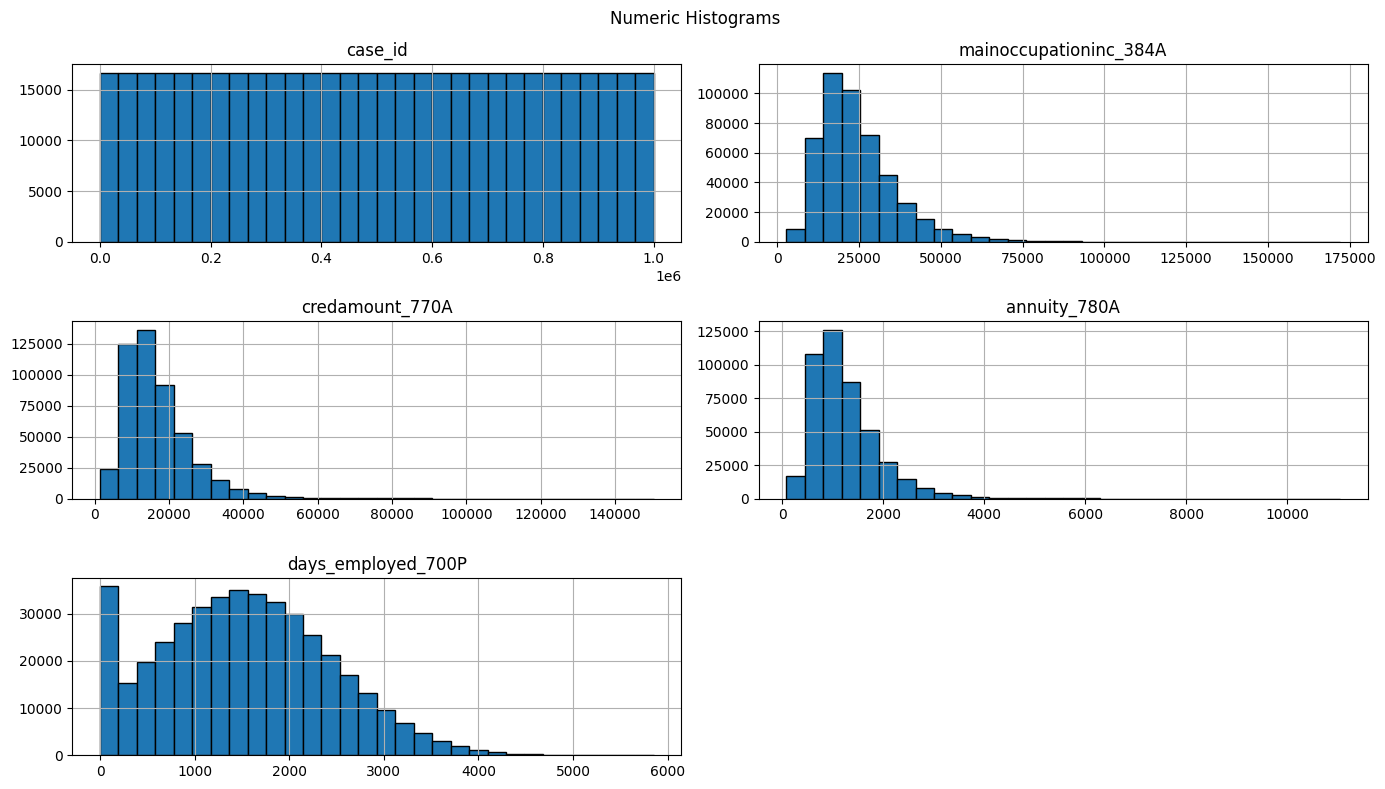


OUTLIERS BEFORE CLEANING
case_id: 0 outliers (0.00%)
mainoccupationinc_384A: 16,349 outliers (3.27%)
credamount_770A: 18,435 outliers (3.69%)
annuity_780A: 16,840 outliers (3.37%)
days_employed_700P: 1,492 outliers (0.30%)

OUTLIERS AFTER CLEANING
case_id: 0 outliers (0.00%)
mainoccupationinc_384A: 0 outliers (0.00%)
credamount_770A: 0 outliers (0.00%)
annuity_780A: 0 outliers (0.00%)
days_employed_700P: 0 outliers (0.00%)

Missing values before: 159698
Missing values after: 0

Original shape: (500000, 8)
Cleaned shape: (500000, 8)


,case_id,mainoccupationinc_384A,credamount_770A,annuity_780A,days_employed_700P,education_927M,maritalstatus_703M,birth_259D
0,2,25386.0,13707.0,725.0,1502.0,10795bac,ea6fb4b5,1952-01-27
1,4,31763.0,35917.0,830.0,355.0,6def22f0,e78cb9c0,1962-12-24
2,6,12166.0,9069.0,1071.0,1424.0,242b264b,f62a4fc7,1981-08-12
3,8,15939.0,18323.0,1097.0,1502.0,6def22f0,f62a4fc7,1967-05-28
4,10,17947.0,19116.0,750.0,493.0,10795bac,ea6fb4b5,1978-09-16


In [46]:
from google.colab import files

# Upload one CSV file from your computer
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Read the CSV file into a table called df
df = pd.read_csv(file_name)

# Create the preprocessing tool
preprocessor = SimplePreprocessor()

# Study the original data and save cleaning rules
preprocessor.fit(df)

# Show EDA before cleaning the data
print("EDA BEFORE CLEANING")
preprocessor.eda(df)

# Show possible outliers before cleaning
print("\nOUTLIERS BEFORE CLEANING")
preprocessor.outliers(df)

# Fill missing values and cap very high or very low values
clean_df = preprocessor.transform(
    df,
    cap_outliers=True
)

# Test whether outliers were handled
print("\nOUTLIERS AFTER CLEANING")
preprocessor.outliers(clean_df)

# Test whether missing values were handled
print("\nMissing values before:", df.isna().sum().sum())
print("Missing values after:", clean_df.isna().sum().sum())

# Check that no rows or columns disappeared
print("\nOriginal shape:", df.shape)
print("Cleaned shape:", clean_df.shape)

# Show the first five cleaned rows
clean_df.head()

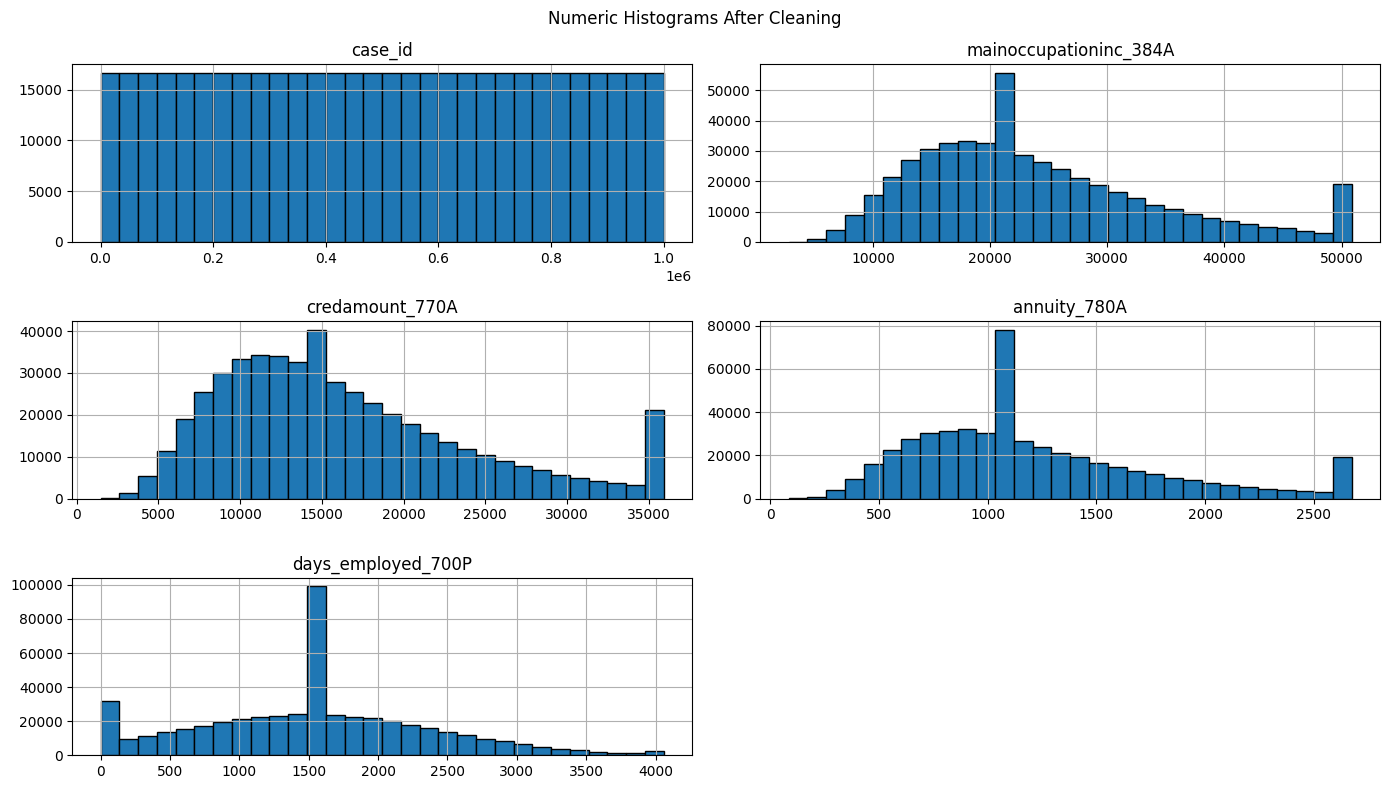

In [47]:
# Histograms after cleaning
clean_df[preprocessor.num_cols].hist(
    bins=30,
    figsize=(14, 8),
    edgecolor="black"
)

plt.suptitle("Numeric Histograms After Cleaning")
plt.tight_layout()
plt.show()